#AB pet-project

В этом проекте я анализирую реальные логи визитов пользователей сайта Физтех.Статистики (выгрузка Яндекс.Метрики, период с 2020 года) и на их основе проектирую A/B-эксперимент, проверяя статистические методы на исторических данных.

Данные: одна строка = один визит. В датасете есть идентификаторы визита и пользователя, время визита, глубина просмотра (pageViews), длительность (visitDuration), флаги new/bounce, география (страна/город) и технические параметры (браузер, ОС, тип сети, характеристики экрана/окна).

Что я делаю в проекте:

Провожу EDA: объём данных, временной охват, уникальные пользователи, динамика визитов по дням, распределения глубины/длительности, топ стран/браузеров/ОС и базовая очистка/укрупнение редких категорий.

Формулирую и дизайню эксперимент на 4 недели: изменение визуального оформления сайта (розовый фон + анимированные элементы).
Гипотеза: средняя глубина просмотра на пользователя вырастет на 5%.

Настраиваю схему эксперимента: длительность, размер выборки, разбиение на test/control, целевая метрика (mean pageViews на пользователя).

Провожу валидацию критериев на исторических данных через симуляции:

серии AA-тестов для проверки корректности (ошибка I рода ≈ α),

серии AB-тестов с искусственно добавленным эффектом для оценки мощности и построения power-кривых (оценка MDE).

Результат: воспроизводимый пайплайн от разведочного анализа до выбора статистического подхода, с оценкой корректности, мощности.

In [ ]:
import scipy.stats as st
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00


# EDA

In [ ]:
data = pd.read_csv('data.tsv', delimiter='\t')
data

,ym:s:visitID,ym:s:clientID,ym:s:dateTimeUTC,ym:s:startURL,ym:s:endURL,ym:s:pageViews,ym:s:visitDuration,ym:s:isNewUser,ym:s:bounce,ym:s:regionCountry,...,ym:s:browserCountry,ym:s:mobilePhone,ym:s:operatingSystemRoot,ym:s:browser,ym:s:browserEngine,ym:s:screenOrientation,ym:s:screenWidth,ym:s:screenHeight,ym:s:windowClientWidth,ym:s:windowClientHeight
0,18016862147439955317,1568056026568729022,2020-01-01 03:28:50,https://mipt-stats.gitlab.io/jekyll/update/201...,https://mipt-stats.gitlab.io/jekyll/update/201...,1.0,1.0,0.0,1.0,Russia,...,gb,NaN,gnu_linux,chrome,WebKit,2.0,1920.0,1080.0,1905.0,981.0
1,18023588058416221520,1577864187752491163,2020-01-01 10:36:27,https://mipt-stats.gitlab.io/jekyll/update/201...,https://mipt-stats.gitlab.io/jekyll/update/201...,9.0,215.0,1.0,0.0,Singapore,...,us,apple,ios_double,safari_mobile,WebKit,1.0,375.0,667.0,375.0,559.0
2,18024599086634569546,1567765219104836417,2020-01-01 11:40:44,https://mipt-stats.gitlab.io/,https://mipt-stats.gitlab.io/jekyll/update/201...,2.0,88.0,0.0,0.0,Russia,...,ru,apple,ios_double,yandex_browser,WebKit,1.0,414.0,736.0,414.0,660.0
3,18024748097052806658,1576839432510419026,2020-01-01 11:50:13,https://mipt-stats.gitlab.io/jekyll/update/201...,https://mipt-stats.gitlab.io/jekyll/update/201...,1.0,19.0,0.0,0.0,China,...,ru,samsung,android,chromemobile,WebKit,1.0,412.0,892.0,412.0,756.0
4,18025178054414241121,1576246599115183097,2020-01-01 12:17:33,https://mipt-stats.gitlab.io/,https://mipt-stats.gitlab.io/jekyll/update/201...,2.0,2.0,0.0,0.0,Russia,...,ru,NaN,gnu_linux,firefox,Gecko,2.0,1920.0,1080.0,913.0,942.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22315,5218320706062192071,0,2020-09-06 12:31:53,https://wiki.yandex.ru/,https://wiki.yandex.ru/homepage/ds-potok-3-kur...,7.0,21.0,0.0,0.0,Russia,...,NaN,NaN,gnu_linux,firefox,Gecko,0.0,0.0,0.0,0.0,0.0
22316,5218479637327974137,0,2020-09-06 12:42:00,https://wiki.yandex.ru/,https://wiki.yandex.ru/homepage/,5.0,28.0,0.0,0.0,Russia,...,NaN,NaN,windows,chrome,WebKit,0.0,0.0,0.0,0.0,0.0
22317,5218527302612618633,0,2020-09-06 12:45:01,https://wiki.yandex.ru/,https://wiki.yandex.ru/homepage/ds-potok-3-kur...,3.0,13.0,0.0,0.0,Russia,...,NaN,NaN,android,chromemobile,WebKit,0.0,0.0,0.0,0.0,0.0
22318,5218540718692175530,0,2020-09-06 12:45:53,https://wiki.yandex.ru/,https://wiki.yandex.ru/homepage/ds-potok-3-kur...,3.0,14.0,0.0,0.0,Russia,...,NaN,NaN,windows,chrome,WebKit,0.0,0.0,0.0,0.0,0.0


#### Преобразуем колонки

In [ ]:
for col in data.columns:
  col_renamed = col.replace("ym:s:", "")
  data.rename(columns={col:col_renamed}, inplace = True)

data["dateTimeUTC"] = pd.to_datetime(data["dateTimeUTC"])

data.head()

,visitID,clientID,dateTimeUTC,startURL,endURL,pageViews,visitDuration,isNewUser,bounce,regionCountry,...,browserCountry,mobilePhone,operatingSystemRoot,browser,browserEngine,screenOrientation,screenWidth,screenHeight,windowClientWidth,windowClientHeight
0,18016862147439955317,1568056026568729022,2020-01-01 03:28:50,https://mipt-stats.gitlab.io/jekyll/update/201...,https://mipt-stats.gitlab.io/jekyll/update/201...,1.0,1.0,0.0,1.0,Russia,...,gb,NaN,gnu_linux,chrome,WebKit,2.0,1920.0,1080.0,1905.0,981.0
1,18023588058416221520,1577864187752491163,2020-01-01 10:36:27,https://mipt-stats.gitlab.io/jekyll/update/201...,https://mipt-stats.gitlab.io/jekyll/update/201...,9.0,215.0,1.0,0.0,Singapore,...,us,apple,ios_double,safari_mobile,WebKit,1.0,375.0,667.0,375.0,559.0
2,18024599086634569546,1567765219104836417,2020-01-01 11:40:44,https://mipt-stats.gitlab.io/,https://mipt-stats.gitlab.io/jekyll/update/201...,2.0,88.0,0.0,0.0,Russia,...,ru,apple,ios_double,yandex_browser,WebKit,1.0,414.0,736.0,414.0,660.0
3,18024748097052806658,1576839432510419026,2020-01-01 11:50:13,https://mipt-stats.gitlab.io/jekyll/update/201...,https://mipt-stats.gitlab.io/jekyll/update/201...,1.0,19.0,0.0,0.0,China,...,ru,samsung,android,chromemobile,WebKit,1.0,412.0,892.0,412.0,756.0
4,18025178054414241121,1576246599115183097,2020-01-01 12:17:33,https://mipt-stats.gitlab.io/,https://mipt-stats.gitlab.io/jekyll/update/201...,2.0,2.0,0.0,0.0,Russia,...,ru,NaN,gnu_linux,firefox,Gecko,2.0,1920.0,1080.0,913.0,942.0


#### Колонки и типы

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22320 entries, 0 to 22319
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   visitID              22320 non-null  uint64        
 1   clientID             22320 non-null  uint64        
 2   dateTimeUTC          22320 non-null  datetime64[ns]
 3   startURL             22305 non-null  object        
 4   endURL               22305 non-null  object        
 5   pageViews            22319 non-null  float64       
 6   visitDuration        22319 non-null  float64       
 7   isNewUser            22319 non-null  float64       
 8   bounce               22319 non-null  float64       
 9   regionCountry        22130 non-null  object        
 10  regionCity           20529 non-null  object        
 11  networkType          2415 non-null   object        
 12  browserLanguage      15699 non-null  object        
 13  browserCountry       13208 non-

#### Пропущенные значения

In [ ]:
print("Number of missing values\n")
for col in data.columns:
  print(f"{col}: {data[col].isna().sum()}")

Number of missing values

visitID: 0
clientID: 0
dateTimeUTC: 0
startURL: 15
endURL: 15
pageViews: 1
visitDuration: 1
isNewUser: 1
bounce: 1
regionCountry: 190
regionCity: 1791
networkType: 19905
browserLanguage: 6621
browserCountry: 9112
mobilePhone: 17885
operatingSystemRoot: 11
browser: 11
browserEngine: 1
screenOrientation: 1
screenWidth: 1
screenHeight: 1
windowClientWidth: 1
windowClientHeight: 1


#### Некоторые полезные сведения

In [ ]:
print(f"Всего визитов: {len(data)}")
print(f"Первый визит: {data['dateTimeUTC'].min()}")
print(f"Последний визит: {data['dateTimeUTC'].max()}")
print(f"Количество уникальных пользователей: {data['clientID'].nunique()}")

visits_count = data.groupby(by="clientID")['visitID'].nunique()
print(f"В среднем пользователь совершает визитов: {visits_count.mean():.2f}")
print(f"Максимум совершено визитов: {visits_count.max()}")

Всего визитов: 22320
Первый визит: 2020-01-01 03:28:50
Последний визит: 2020-09-06 12:52:58
Количество уникальных пользователей: 3727
В среднем пользователь совершает визитов: 5.99
Максимум совершено визитов: 6529


#### Работа с датами

In [ ]:
data['date'] = data['dateTimeUTC'].dt.date
data['hour'] = data['dateTimeUTC'].dt.hour
data['day'] = data['dateTimeUTC'].dt.day
data['month'] = data['dateTimeUTC'].dt.month

data["date"] = pd.to_datetime(data["date"])

data.head()

,visitID,clientID,dateTimeUTC,startURL,endURL,pageViews,visitDuration,isNewUser,bounce,regionCountry,...,browserEngine,screenOrientation,screenWidth,screenHeight,windowClientWidth,windowClientHeight,date,hour,day,month
0,18016862147439955317,1568056026568729022,2020-01-01 03:28:50,https://mipt-stats.gitlab.io/jekyll/update/201...,https://mipt-stats.gitlab.io/jekyll/update/201...,1.0,1.0,0.0,1.0,Russia,...,WebKit,2.0,1920.0,1080.0,1905.0,981.0,2020-01-01,3,1,1
1,18023588058416221520,1577864187752491163,2020-01-01 10:36:27,https://mipt-stats.gitlab.io/jekyll/update/201...,https://mipt-stats.gitlab.io/jekyll/update/201...,9.0,215.0,1.0,0.0,Singapore,...,WebKit,1.0,375.0,667.0,375.0,559.0,2020-01-01,10,1,1
2,18024599086634569546,1567765219104836417,2020-01-01 11:40:44,https://mipt-stats.gitlab.io/,https://mipt-stats.gitlab.io/jekyll/update/201...,2.0,88.0,0.0,0.0,Russia,...,WebKit,1.0,414.0,736.0,414.0,660.0,2020-01-01,11,1,1
3,18024748097052806658,1576839432510419026,2020-01-01 11:50:13,https://mipt-stats.gitlab.io/jekyll/update/201...,https://mipt-stats.gitlab.io/jekyll/update/201...,1.0,19.0,0.0,0.0,China,...,WebKit,1.0,412.0,892.0,412.0,756.0,2020-01-01,11,1,1
4,18025178054414241121,1576246599115183097,2020-01-01 12:17:33,https://mipt-stats.gitlab.io/,https://mipt-stats.gitlab.io/jekyll/update/201...,2.0,2.0,0.0,0.0,Russia,...,Gecko,2.0,1920.0,1080.0,913.0,942.0,2020-01-01,12,1,1


#### Динамика количества визитов

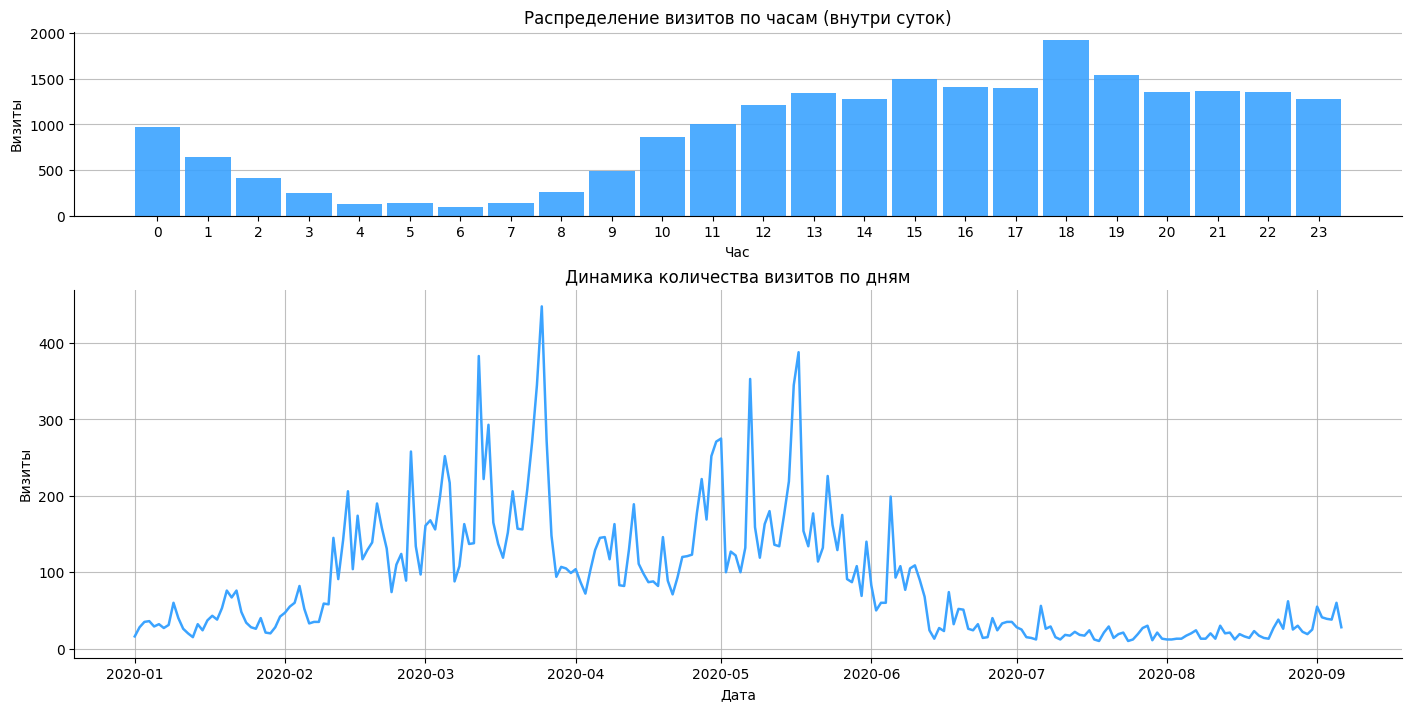

In [ ]:
visits_by_day = data.groupby("date")["clientID"].size()
visits_by_hour = (
    data.groupby("hour")["clientID"].size()
    .reindex(range(24), fill_value=0)
)

BLUE = "#3BA3FF"

fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, figsize=(14, 7),
    gridspec_kw={"height_ratios": [1, 2]},
    constrained_layout=True
)

ax_top.bar(visits_by_hour.index, visits_by_hour.values, color=BLUE, alpha=0.9, width=0.9)
ax_top.set_title("Распределение визитов по часам (внутри суток)")
ax_top.set_xlabel("Час")
ax_top.set_ylabel("Визиты")
ax_top.set_xticks(range(24))
ax_top.grid(True, axis="y", alpha=0.8)
ax_top.set_axisbelow(True)
ax_top.spines["top"].set_visible(False)
ax_top.spines["right"].set_visible(False)

ax_bottom.plot(visits_by_day.index, visits_by_day.values, color=BLUE, linewidth=1.8)
ax_bottom.set_title("Динамика количества визитов по дням")
ax_bottom.set_xlabel("Дата")
ax_bottom.set_ylabel("Визиты")
ax_bottom.grid(True, alpha=0.8)
ax_bottom.set_axisbelow(True)
ax_bottom.spines["top"].set_visible(False)
ax_bottom.spines["right"].set_visible(False)

plt.show()

- Основная активность пользователей приходится на дневные и вечерние часы, пик около 18:00, минимум — ранним утром.

- По дням наблюдаются заметные колебания визитов с отдельными резкими всплесками в конце периода.

#### Глубина и длительность визита

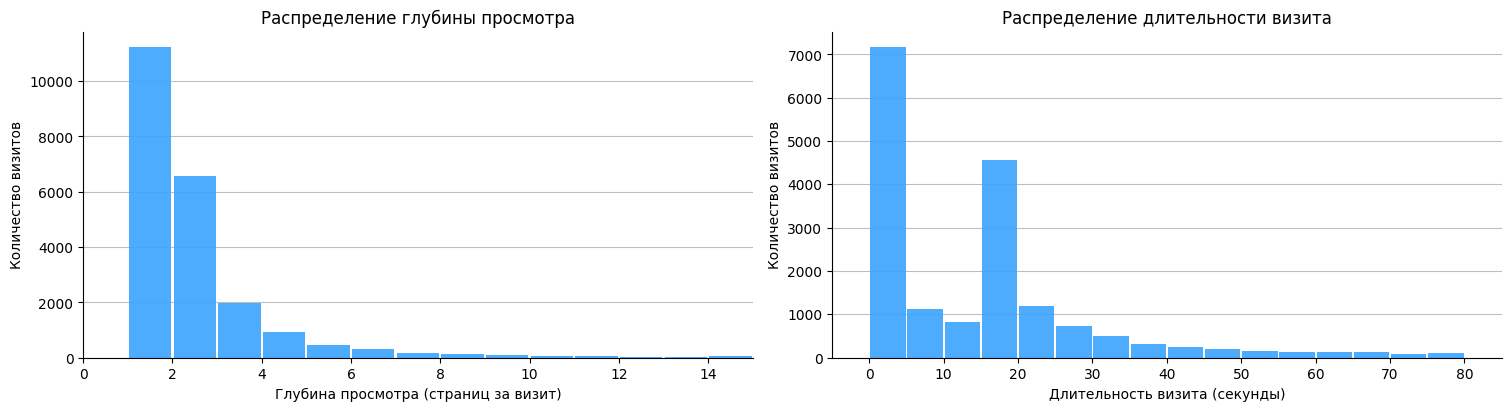

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4), constrained_layout=True)

bins_depth = np.arange(1, 16)
axes[0].hist(data["pageViews"].dropna(), bins=bins_depth, color=BLUE, alpha=0.9, rwidth=0.95)
axes[0].set_title("Распределение глубины просмотра")
axes[0].set_xlabel("Глубина просмотра (страниц за визит)")
axes[0].set_ylabel("Количество визитов")
axes[0].set_xlim(0, 15)
axes[0].grid(True, axis="y", alpha=0.8)
axes[0].set_axisbelow(True)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

bins_dur = np.arange(0, 85, 5)
axes[1].hist(data["visitDuration"].dropna(), bins=bins_dur, color=BLUE, alpha=0.9, rwidth=0.95)
axes[1].set_title("Распределение длительности визита")
axes[1].set_xlabel("Длительность визита (секунды)")
axes[1].set_ylabel("Количество визитов")
axes[1].set_xlim(-5, 85)
axes[1].grid(True, axis="y", alpha=0.8)
axes[1].set_axisbelow(True)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.show()

- Большинство визитов короткие и неглубокие: чаще всего пользователи просматривают 1–3 страницы и проводят на сайте менее 10–20 секунд.

- Оба распределения имеют длинный «хвост», что указывает на наличие небольшой доли более вовлечённых пользователей с длительными и глубокими сессиями, а также возможные выбросы в данных. Длительность визита имеет странный всплеск на 15-20 секундах

#### Посмотрим на стартовый URL

In [ ]:
data['startURL'].value_counts().nlargest(15)

,count
startURL,
https://mipt-stats.gitlab.io/,4533
https://mipt-stats.gitlab.io/jekyll/update/2020/02/01/ad.html,3880
https://wiki.yandex.ru/homepage/3spring20/,2957
https://wiki.yandex.ru/,2759
https://mipt-stats.gitlab.io/jekyll/update/2020/02/01/ms.html,2200
https://mipt-stats.gitlab.io/jekyll/update/2019/09/02/statistics-applied.html,985
https://mipt-stats.gitlab.io/jekyll/update/2019/09/02/bayes.html,311
https://mipt-stats.gitlab.io/jekyll/update/2020/02/01/ad.html#homework,280
https://wiki.yandex.ru/?status=ok,268


#### Функция для отрисовки красивых пайчартов

In [ ]:
import matplotlib.pyplot as plt

colors = ['#1E88E5', '#42A5F5', '#64B5F6', '#90CAF9',
          '#1565C0', '#0D47A1', '#2196F3', '#03A9F4', '#00BCD4']

def create_pretty_pie(data_series, title, figsize=(6, 6), exclude_other_if_small=True, min_percent=1):
    data_series = data_series.sort_values(ascending=False)

    total = data_series.sum()
    if exclude_other_if_small and 'other' in data_series.index:
        other_pct = data_series['other'] / total * 100
        if other_pct < min_percent:
            data_series = data_series[data_series.index != 'other']
            title += f" (other <{min_percent}% исключен)"

    fig, ax = plt.subplots(figsize=figsize)

    wedges, texts, autotexts = ax.pie(
        data_series.values,
        labels=data_series.index,
        autopct='%1.1f%%',
        colors=colors[:len(data_series)],
        startangle=90,
        textprops={'fontsize': 10, 'weight': 'bold', 'color': '#1E3A5F'},
        wedgeprops={
            'edgecolor': 'white',
            'linewidth': 1.5,
            'antialiased': True
        },
        pctdistance=0.8,
        labeldistance=1.05
    )

    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_weight('bold')
        autotext.set_fontsize(9)

    centre_circle = plt.Circle((0, 0), 0.70, fc='white', linewidth=0, alpha=0.9)
    ax.add_artist(centre_circle)

    ax.set_title(title, fontsize=12, weight='bold', color='#0D47A1', pad=15)
    ax.set_ylabel('')
    ax.axis('equal')

    plt.tight_layout()
    plt.show()

    return data_series

#### Основные источники перехода

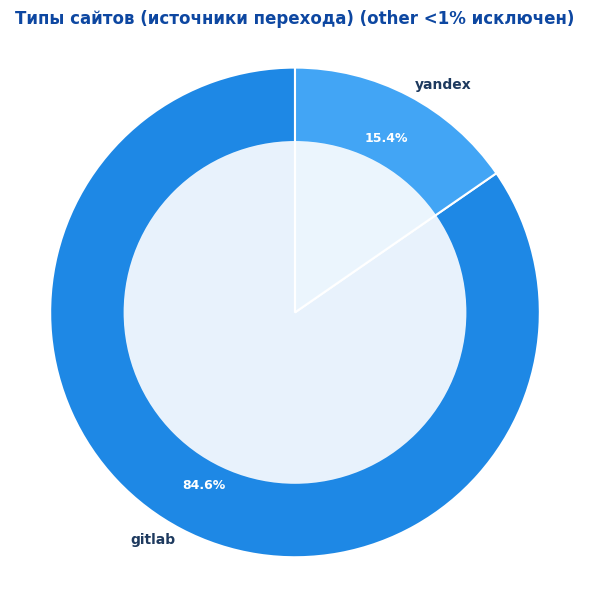

,clientID
startURL,
gitlab,3176
yandex,577


In [ ]:
def site_type(url):
  url_lower = url.lower()

  if 'gitlab' in url:
    return 'gitlab'
  elif 'yandex' in url:
    return 'yandex'
  elif 'github' in url:
    return 'github'
  else:
    return 'other'

data['startURL'] = data['startURL'].astype(str)
data['startURL'] = data['startURL'].apply(site_type)

site_stats = data.groupby('startURL')['clientID'].nunique()
create_pretty_pie(site_stats, 'Типы сайтов (источники перехода)')

#### Основные ОС пользователей

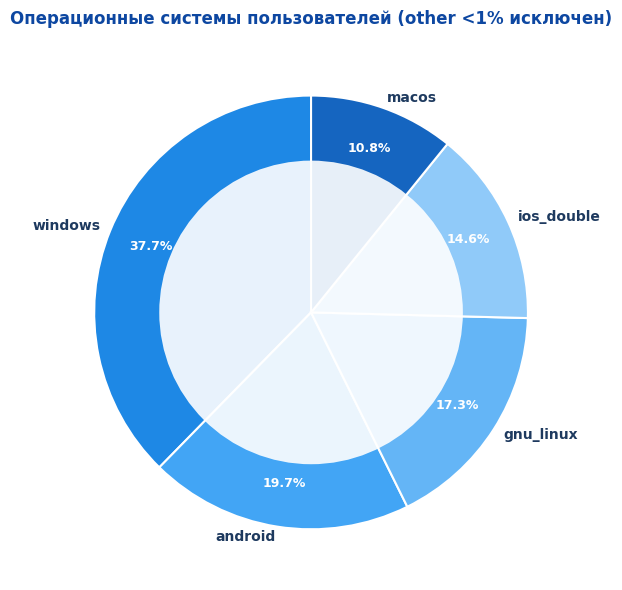

,clientID
operatingSystemRoot,
windows,1405
android,733
gnu_linux,644
ios_double,544
macos,404


In [ ]:
data['operatingSystemRoot'] = data['operatingSystemRoot'].astype(str)

data['operatingSystemRoot'] = data['operatingSystemRoot'].where(data['operatingSystemRoot'].isin(["windows", "gnu_linux",
                                                                                                  "android", "macos", "ios_double"]), 'other')

os_stats = data.groupby('operatingSystemRoot')['clientID'].nunique()
create_pretty_pie(os_stats, 'Операционные системы пользователей')

In [ ]:
data['browser'].value_counts().nlargest(10)

,count
browser,
chrome,9066
firefox,2778
chromemobile,2653
yandex_browser,2525
safari,1678
safari_mobile,1381
opera,1064
chromium,483
miui,201


#### Основные браузеры пользователей

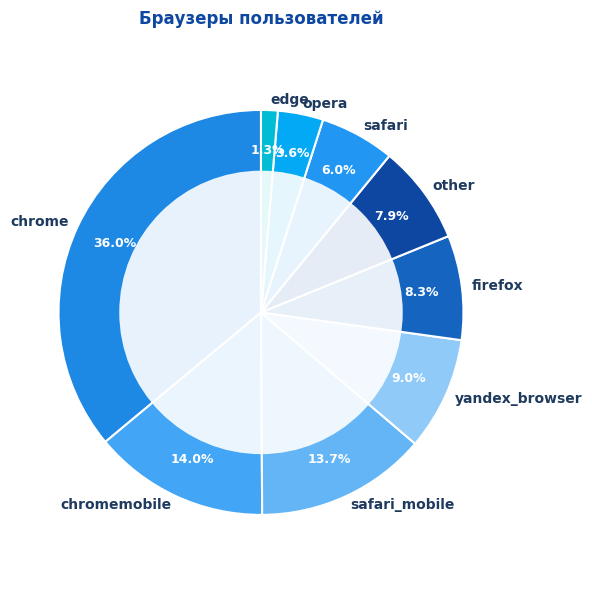

,clientID
browser,
chrome,1352
chromemobile,527
safari_mobile,513
yandex_browser,339
firefox,313
other,297
safari,224
opera,136
edge,50


In [ ]:
data['browser'] = data['browser'].astype(str)

data['browser'] = data['browser'].where(data['browser'].isin(["chrome", "yandex_browser",
                                                              "chromemobile", "firefox", "safari",
                                                              "safari_mobile", "opera", "edge"]), 'other')

browser_stats = data.groupby('browser')['clientID'].nunique()
create_pretty_pie(browser_stats, 'Браузеры пользователей')

In [ ]:
data.groupby('regionCountry')['clientID'].nunique().nlargest(5)

,clientID
regionCountry,
Russia,3401
United States,64
Belarus,51
Canada,44
Kazakhstan,21


Почти все пользователи из России

In [ ]:
data['regionCountry'] = data['regionCountry'].astype(str)

data.loc[data['regionCountry'] != 'Russia', 'regionCountry'] = 'other'

data.groupby('regionCountry')['clientID'].nunique().sort_values(ascending=False)

,clientID
regionCountry,
Russia,3401
other,391


#### Количество уникальных пользователей по месяцам

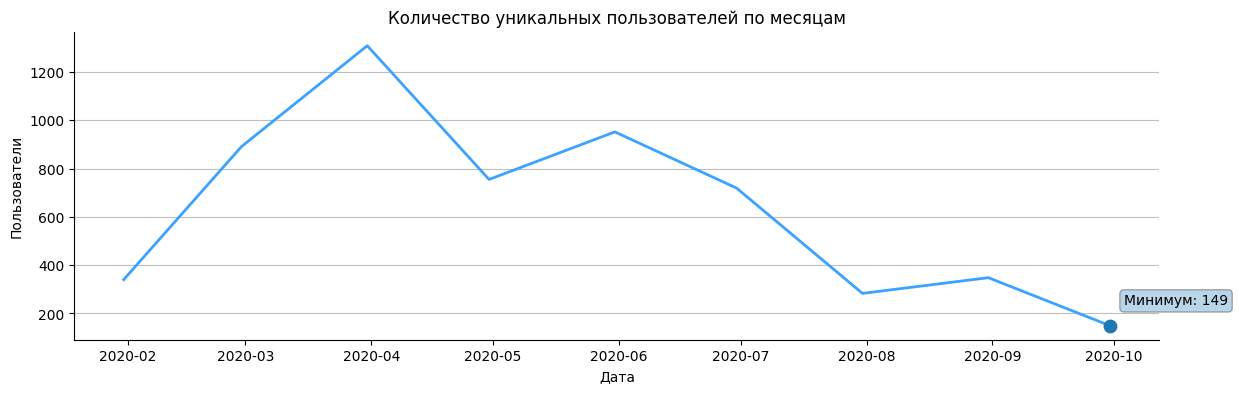

In [ ]:
BLUE = "#3BA3FF"

monthly_users = (
    data.set_index("date")
      .resample("M")["clientID"]
      .nunique()
)

fig, ax = plt.subplots(figsize=(14,4))

ax.plot(
    monthly_users.index,
    monthly_users.values,
    color=BLUE,
    linewidth=2
)

min_date = monthly_users.idxmin()
min_value = monthly_users.min()

ax.scatter(
    min_date,
    min_value,
    s=80,
    zorder=3
)

ax.annotate(
    f"Минимум: {min_value}",
    xy=(min_date, min_value),
    xytext=(10, 15),
    textcoords="offset points",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", alpha=0.3)
)

ax.set_title("Количество уникальных пользователей по месяцам")
ax.set_xlabel("Дата")
ax.set_ylabel("Пользователи")

ax.grid(True, axis="y", alpha=0.8)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

Заметим, что в датасете крайне мало уникальных пользователей. Нижняя оценка это 149 пользователей в месяц. Количество пользователей снижается к концу рассматриваемого периода.

## Гипотеза
#### Планируется проверить, увеличивает ли изменение визуального оформления сайта среднюю глубину просмотра на пользователя на 5% при уровне значимости 0.05 и требуемой мощности теста 0.8.


#### Функция для генерации двух подвыборок для эксперимента

Случайным образом разбивает пользователей на 2 группы в рамках рассматриваемого периода и заданной длительности эксперимента. Возвращает тестовую и контрольную подвыборки.

In [ ]:
def generate_sample(
    data,
    validation_start,
    validation_end,
    days,
    total_users,
    ratio_test,
    date_column,
    user_column,
    target_column,
    seed):

  rng = np.random.default_rng(seed=seed)

  validation_start = pd.to_datetime(validation_start)
  validation_end = pd.to_datetime(validation_end)

  max_start = validation_end - pd.Timedelta(days=days)
  n_days = (max_start - validation_start).days
  start_date = validation_start + pd.Timedelta(days = rng.integers(low = 0, high = n_days + 1))
  end_date = start_date + pd.Timedelta(days=days)

  trunc_data = data[(data[date_column] >= start_date) & (data[date_column] < end_date)]
  users = trunc_data[user_column].dropna().unique()

  if len(users) < total_users:
      raise ValueError(
          f"В окне {start_date.date()}..{end_date.date()} всего {len(users)} юзеров, нужно {total_users}. "
          "Либо уменьшай total_users, либо расширяй диапазон дат для валидации."
      )

  sample_users = rng.choice(users, size=total_users, replace=False)

  test_size = total_users * ratio_test
  control_size = total_users - test_size

  rng.shuffle(sample_users)
  test_users = sample_users[:int(test_size)]
  control_users = sample_users[int(test_size):]

  test = trunc_data[trunc_data[user_column].isin(test_users)].groupby(user_column)[target_column].mean()
  control = trunc_data[trunc_data[user_column].isin(control_users)].groupby(user_column)[target_column].mean()

  return {'test': test,
          'control': control}

#### Функция для проведения Т-теста
Расчитывает статистику, p-value и доверительный интервал. Если по каким-то причинам дисперсии выборок разные, то можно проветси тест Уэлча (equal_var = True).

In [ ]:
from scipy import stats as sps

def welch_test(x, y, alpha=0.05, alternative='two-sided', equal_var=False):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    n_x = x.size
    n_y = y.size

    mx = np.mean(x)
    my = np.mean(y)
    vx = np.var(x, ddof=1)
    vy = np.var(y, ddof=1)

    if equal_var:
        sp = np.sqrt(((n_x - 1) * vx + (n_y - 1) * vy) / (n_x + n_y - 2))
        se = sp * np.sqrt(1.0 / n_x + 1.0 / n_y)
        df = n_x + n_y - 2
    else:
        se2 = vx / n_x + vy / n_y
        se = np.sqrt(se2)
        df = (se2 ** 2) / (((vx / n_x) ** 2) / (n_x - 1) + ((vy / n_y) ** 2) / (n_y - 1))

    diff = mx - my
    t_stat = diff / se
    pvalue = 2.0 * sps.t.sf(np.abs(t_stat), df)

    if alternative == 'two-sided':
        pvalue = 2.0 * sps.t.sf(np.abs(t_stat), df)
        q = sps.t.ppf(1.0 - alpha / 2.0, df)
        left_ci = diff - q * se
        right_ci = diff + q * se

    elif alternative == 'greater':
        pvalue = sps.t.sf(t_stat, df)
        left_ci, right_ci = np.nan, np.nan

    elif alternative == 'less':
        pvalue = sps.t.cdf(t_stat, df)
        left_ci, right_ci = np.nan, np.nan

    return {'t_stat': t_stat, 'pvalue': pvalue, 'left_ci': left_ci, 'right_ci': right_ci}

#### Ratio-тест
Для нашей целевой переменной не используется, но может потребоваться для развития pet-проекта и тестирования изменений в конверсиях.

In [ ]:
def ratio_test(x, y, alpha = 0.05, alternative = 'two-sided'):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    n = len(x)

    mx = np.mean(x)
    my = np.mean(y)
    vx = np.var(x, ddof=1)
    vy = np.var(y, ddof=1)

    stat = mx/my - 1
    var = vx/np.pow(my, 2) + (np.pow(mx, 2) * vy)/(np.pow(my, 4))
    se = np.sqrt(var/n)

    z_stat = stat/se
    if alternative == 'two-sided':
        pvalue = 2.0 * sps.norm.sf(np.abs(z_stat))
        q = sps.norm.ppf(1.0 - alpha / 2.0)
        left_ci = stat - q * se
        right_ci = stat + q * se

    elif alternative == 'greater':
        pvalue = sps.norm.sf(z_stat)
        left_ci, right_ci = np.nan, np.nan

    elif alternative == 'less':
        pvalue = sps.norm.cdf(z_stat)
        left_ci, right_ci = np.nan, np.nan

    return {'z_stat': z_stat, 'pvalue': pvalue, 'left_ci': left_ci, 'right_ci': right_ci}

#### Симуляция AA тестов для проверки

In [ ]:
def simulate_AA(
    n_iters,
    alpha = 0.05,
    absolute_test = True,
    alternative = 'two-sided',
    equal_var = False,
    **gen_kwargs):
  n_rejects = 0
  for _ in range(n_iters):
    sample = generate_sample(**gen_kwargs)
    if absolute_test:
      result = welch_test(sample['test'], sample['control'], alpha=alpha, alternative=alternative, equal_var=equal_var)
    else:
      result = ratio_test(sample['test'], sample['control'], alpha=alpha, alternative=alternative)
    if result['pvalue'] < alpha:
      n_rejects += 1

  return n_rejects

#### Искусственное добавление эффекта

In [ ]:
def add_relative_effect(x: np.ndarray, effect: float):
    return x * (1.0 + effect)

Доверительные интервалы

In [ ]:
from statsmodels.stats.proportion import proportion_confint

def reject_rate_ci(n_rejects: int, n_iters: int, alpha: float = 0.05):
    rate = n_rejects / n_iters
    left, right = proportion_confint(n_rejects, n_iters, alpha=alpha, method="wilson")
    return rate, left, right

def alpha_ci(n_rejects, n_iters, method="wilson"):
    rate = n_rejects / n_iters
    left, right = proportion_confint(n_rejects, n_iters, method=method)
    return rate, left, right

#### Расчет мощности теста

In [ ]:
def simulate_power(
    n_iters,
    effects,
    alpha = 0.05,
    alternative='two-sided',
    absolute_test=True,
    equal_var=False,
    **gen_kwargs):

  powers = []
  cis = []

  for eff in effects:
    rejects = 0
    for _ in range(n_iters):
      sample = generate_sample(**gen_kwargs)

      test_eff = add_relative_effect(sample['test'], eff)
      if absolute_test:
        result = welch_test(test_eff, sample['control'], alpha=alpha, alternative=alternative, equal_var=equal_var)
      else:
        result = ratio_test(test_eff, sample['control'], alpha=alpha, alternative=alternative)
      if result['pvalue'] < alpha:
        rejects += 1
    powers.append(rejects/n_iters)
    rate, left, right = reject_rate_ci(rejects, n_iters, alpha=0.05)
    cis.append((left, right))

  powers = np.array(powers)
  left = np.array([c[0] for c in cis])
  right = np.array([c[1] for c in cis])

  return powers, left, right

In [ ]:
def plot_power(effects, powers, left, right, label):
    plt.figure(figsize=(9, 4))
    plt.plot(effects, powers, label=label, linewidth=2)
    plt.fill_between(effects, left, right, alpha=0.2)
    plt.axhline(0.8, linestyle="--", linewidth=2)
    plt.ylim(0, 1)
    plt.xlabel("Относительный эффект")
    plt.ylabel("Мощность")
    plt.title("Power curve")
    plt.legend()
    plt.show()

Количество уникальных пользователей в периоде

In [70]:
def max_total_users_for_windows(data, start, end, window_days=28, date_col="date", user_col="clientID"):
    start = pd.to_datetime(start)
    end = pd.to_datetime(end)

    df = data[(data[date_col] >= start) & (data[date_col] < end)].copy()
    df[date_col] = pd.to_datetime(df[date_col])

    max_start = end - pd.Timedelta(days=window_days)
    starts = pd.date_range(start, max_start, freq="D")

    counts = []
    for s in starts:
        e = s + pd.Timedelta(days=window_days)
        u = df[(df[date_col] >= s) & (df[date_col] < e)][user_col].nunique()
        counts.append(u)

    return pd.Series(counts, index=starts)

counts = max_total_users_for_windows(
    data,
    "2020-06-01",
    "2020-07-01",
    window_days=28,
    date_col="date",
    user_col="clientID"
)

print("min uniq users in any 28d window:", int(counts.min()))
print("median:", int(counts.median()))
print("max:", int(counts.max()))

min uniq users in any 28d window: 660
median: 661
max: 687


#### Параметры эксперимента

Для оценки реализуемости эксперимента выбран период со средним уровнем пользовательского трафика: последние месяцы содержат слишком мало наблюдений для проведения теста с достаточной мощностью, а первые — аномально высокий трафик, не отражающий типичный уровень активности пользователей. Поэтому используется репрезентативный промежуточный интервал.

In [72]:
DATE_VALID_START = pd.to_datetime("2020-06-01",)
DATE_VALID_END = pd.to_datetime("2020-07-01",)
WINDOW_DAYS = 28
TOTAL_USERS = 600
RATIO_TEST = 0.5

EFFECTS = np.linspace(0, 0.30, 16)
N_ITER = 1000
ALPHA = 0.05

gen_kwargs = dict(
    data = data,
    validation_start = DATE_VALID_START,
    validation_end = DATE_VALID_END,
    days = WINDOW_DAYS,
    total_users = TOTAL_USERS,
    ratio_test = RATIO_TEST,
    date_column = 'date',
    user_column = 'clientID',
    target_column = 'pageViews',
    seed = None
)

In [73]:
aa_abs = simulate_AA(
    n_iters=N_ITER,
    alpha=ALPHA,
    absolute_test=True,
    **gen_kwargs
)

Проверка ошибки первого рода

In [74]:
rate_abs, l_abs, r_abs = alpha_ci(aa_abs, N_ITER)

print(f"AA t-test:  alpha_hat={rate_abs:.3f}, CI=({l_abs:.3f}, {r_abs:.3f})")
print(f"Target alpha = {ALPHA:.2f}")

AA t-test:  alpha_hat=0.048, CI=(0.036, 0.063)
Target alpha = 0.05


AA-тест показывает корректный контроль уровня значимости

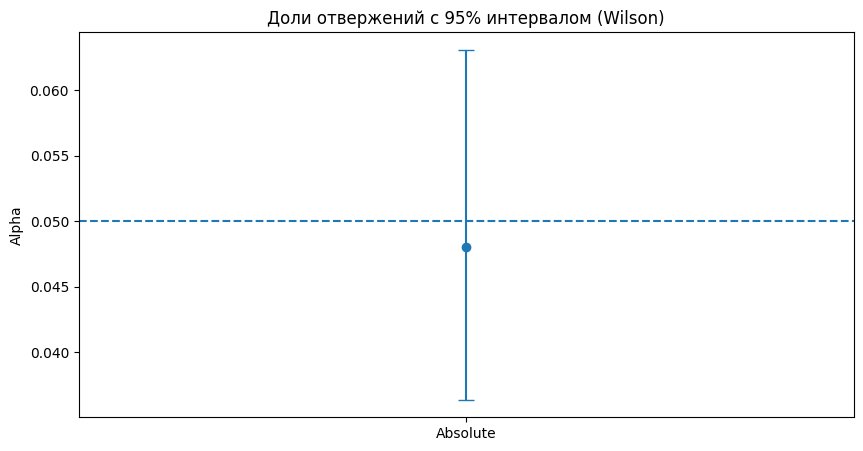

In [75]:
labels = ["Absolute"]
rates = [rate_abs]
lows  = [rate_abs - l_abs]
highs = [r_abs - rate_abs]

plt.figure(figsize=(10,5))
plt.errorbar(labels, rates, yerr=[lows, highs], fmt="o", capsize=6)
plt.axhline(ALPHA, linestyle="--")
plt.ylabel("Alpha")
plt.title("Доли отвержений с 95% интервалом (Wilson)")
plt.show()

Симуляция мощности

In [76]:
powers_abs, left_abs, right_abs = simulate_power(
    n_iters=N_ITER,
    effects=EFFECTS,
    alpha=ALPHA,
    absolute_test=True,
    **gen_kwargs
)

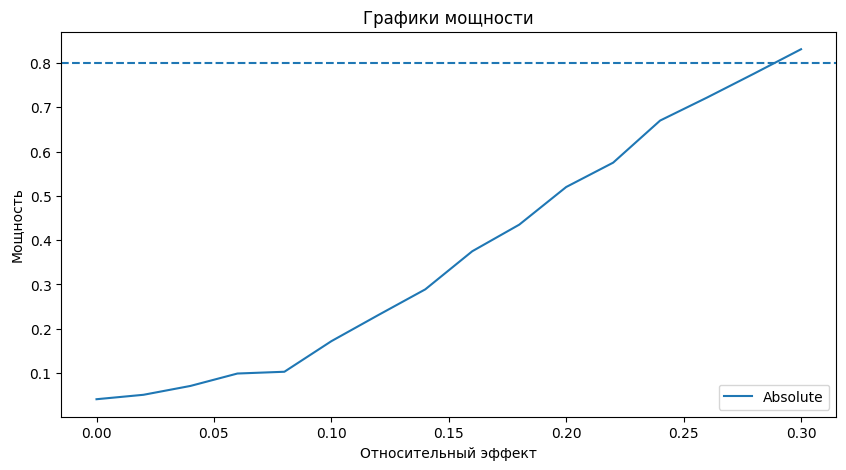

In [77]:
plt.figure(figsize=(10,5))

plt.plot(EFFECTS, powers_abs, label="Absolute")

plt.axhline(0.8, linestyle="--")

plt.xlabel("Относительный эффект")
plt.ylabel("Мощность")
plt.title('Графики мощности')
plt.legend()

plt.show()

По результатам симуляций мощность теста достигает целевого уровня 0.8 только при эффекте порядка 30%. Для ожидаемого эффекта 5% мощность составляет менее 0.1, что делает эксперимент практически неспособным обнаружить такой эффект при выбранном размере выборки и длительности эксперимента.